**V3 · Minimum-variance delta hedging** 🟡

- **Claim:** A Hull–White minimum-variance delta (leverage-effect adjusted) reduces hedging-error variance.
- **Test:** Daily SPY with VIX as the option's implied vol; out-of-sample hedging-variance reduction vs a 0% GBM null.
- **Verdict:** Direction confirmed, but ~88% of the gain is VIX-as-IV leakage, so the headline 49% is construction-inflated (Hull–White report ~26% on real quotes).

*Where this fits: V3, the first of the two amber results; its convexity flip-side is V4. Map: [research/README.md](README.md).*

---

# Real-Data Verification V3 ★: Minimum-Variance Delta Hedging

This is the strongest link from the synthetic work to reality.  In the **synthetic Heston
world** the minimum-variance (MV) delta of Hull–White barely helped, because that world was
calibrated with `v₀ = θ`, leaving **no persistent spot-vol leverage dynamics** for an MV
correction to exploit (the true null there is a **0%** gain).  The hypothesis: on **real
data**, where spot and implied vol move together (the leverage effect), the MV delta should
help.  We test the **direction**, and are upfront that the **magnitude here is inflated**,
because we proxy the option's IV with VIX, the hedging error is dominated by the vol move,
so the gain partly just re-expresses the VIX-vs-spot relationship (quantified below, and
benchmarked against Hull–White 2017's ~26% on real tradeable quotes).

**Setup (reproducible, no option panel needed).** Daily SPY (underlying) and `^VIX` as the
ATM ~1-month implied-vol proxy.  Each day we strike a fresh **ATM 1-month call** at `S_t`
with `IV = VIX_t/100`, hold it one day, and measure the **delta-hedged P&L (hedging
error)** `HE = ΔC − δ·ΔS`.

- **BS delta:** `δ_BS = N(d₁)` with `IV = VIX`.
- **MV delta (Hull–White 2017):** `δ_MV = δ_BS + (vega / (S√τ))·(a + b·δ_BS + c·δ_BS²)`,
  with `(a,b,c)` chosen to minimise the realised squared hedging error, a linear least
  squares of `HE_BS` on the three vega-scaled regressors.

**Metric.** Variance-reduction gain `= 1 − Var(HE_MV) / Var(HE_BS)`, reported both in-sample
and **out-of-sample** (fit `(a,b,c)` on the first half, evaluate on the second).

**Success.** A clearly **positive** gain out-of-sample versus a **0% GBM null**, confirming
the *direction*: real leverage dynamics, absent by construction in the synthetic world, make
the MV delta pay off. The exact percentage is not the claim (it is construction-inflated).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

from scipy import stats

from config import DEFAULT_RISK_FREE_RATE as r
from data.fetcher import fetch_and_cache
from models.black_scholes import BlackScholes

COLORS = {"bs": "steelblue", "mv": "darkorange"}
DATE = "2026-06-20"

def _flat(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy(); df.columns = df.columns.get_level_values(0)
    return df

def fetch_spy():
    import yfinance as yf
    df = _flat(yf.download("SPY", period="10y", auto_adjust=True, progress=False))
    return df[["Close"]].rename(columns={"Close": "close"})

def fetch_vix():
    import yfinance as yf
    df = _flat(yf.download("^VIX", period="10y", auto_adjust=True, progress=False))
    return df[["Close"]].rename(columns={"Close": "vix"})

print("snapshot DATE =", DATE)

snapshot DATE = 2026-06-20


## 1. SPY and VIX, aligned

`^VIX` is the market's ~30-day ATM implied vol, exactly the constant-maturity IV we hedge
the synthetic 1-month option with.

In [2]:
spy = fetch_and_cache("SPY", "prices_10y", DATE, fetch_spy)
vix = fetch_and_cache("VIX", "close_10y", DATE, fetch_vix)
df = spy.join(vix, how="inner").dropna()
S = df["close"].to_numpy(float)
IV = df["vix"].to_numpy(float) / 100.0
dt = 1.0 / 252.0
print(df.index[0].date(), "->", df.index[-1].date(), " | ", len(df), "aligned days")
print("mean VIX =", round(df["vix"].mean(), 1), "%   IV range",
      round(IV.min() * 100, 1), "-", round(IV.max() * 100, 1), "%")

2016-06-20 -> 2026-06-17  |  2513 aligned days
mean VIX = 18.6 %   IV range 9.1 - 82.7 %


## 2. The leverage effect (why an MV correction can exist)

Regress the daily change in VIX on the SPY return.  A strongly **negative** slope (vol
spikes when the market falls) is the dynamic the MV delta exploits and the synthetic
`v₀=θ` world did not have.

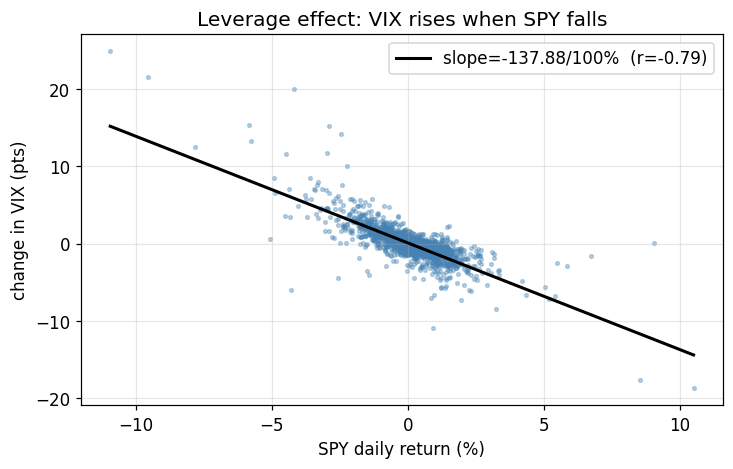

VIX-vs-return slope = -137.88  correlation r = -0.79


In [3]:
dS_rel = np.diff(S) / S[:-1]
dVIX = np.diff(df["vix"].to_numpy(float))
slope, intercept, rval, *_ = stats.linregress(dS_rel, dVIX)
fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.scatter(dS_rel * 100, dVIX, s=6, alpha=0.35, color=COLORS["bs"])
xs = np.linspace(dS_rel.min(), dS_rel.max(), 50)
ax.plot(xs * 100, intercept + slope * xs, color="black", lw=2,
        label=f"slope={slope:.2f}/100%  (r={rval:.2f})")
ax.set_xlabel("SPY daily return (%)"); ax.set_ylabel("change in VIX (pts)")
ax.set_title("Leverage effect: VIX rises when SPY falls"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("VIX-vs-return slope =", round(slope, 2), " correlation r =", round(rval, 2))

## 3. Daily delta-hedged P&L: BS delta vs MV delta

For each day strike an ATM call at `S_t`, `IV=VIX_t`, `τ=1mo`; reprice it one day later at
`S_{t+1}`, `IV=VIX_{t+1}`, `τ−dt`.  `HE_BS = ΔC − δ_BS·ΔS`.  Then fit the Hull–White MV
correction by least squares (in-sample and out-of-sample).

In [4]:
tau = 21.0 / 252.0
dS = np.diff(S)
dBS = np.empty(len(S) - 1); vega = np.empty(len(S) - 1); dC = np.empty(len(S) - 1)
for t in range(len(S) - 1):
    o = BlackScholes(S[t], S[t], tau, r, IV[t])           # ATM, struck at S_t
    dBS[t] = o.delta("call"); vega[t] = o.vega()
    dC[t] = BlackScholes(S[t + 1], S[t], tau - dt, r, IV[t + 1]).price("call") - o.price("call")

HE_bs = dC - dBS * dS
base = vega / (S[:-1] * np.sqrt(tau))
X = np.column_stack([base * dS, base * dBS * dS, base * dBS ** 2 * dS])  # HE_mv = HE_bs - X@coef

def fit_eval(fit, ev):
    coef, *_ = np.linalg.lstsq(X[fit], HE_bs[fit], rcond=None)
    he_mv = HE_bs[ev] - X[ev] @ coef
    return 1 - np.var(he_mv) / np.var(HE_bs[ev]), coef, he_mv

n = len(HE_bs); half = n // 2
g_is,  coef_is,  he_is  = fit_eval(np.arange(n), np.arange(n))
g_oos, coef_oos, he_oos = fit_eval(np.arange(half), np.arange(half, n))
HE_mv_full = HE_bs - X @ coef_is
print("in-sample      variance-reduction gain =", round(g_is * 100, 1), "%")
print("out-of-sample  variance-reduction gain =", round(g_oos * 100, 1),
      "%   (fit 1st half, eval 2nd half)")
print("std(HE_BS) =", round(HE_bs.std(), 4), "  std(HE_MV) =", round(HE_mv_full.std(), 4))

# Leakage diagnostic: because we set IV literally = VIX, most of the hedging error is the
# vol move (vega*dVIX), so the MV gain is largely a "regress dVIX on dS" effect, not a
# tradeable delta improvement. (vega is per 1% vol; IV is decimal -> scale by 100.)
vega_term = vega * np.diff(IV) * 100.0
print("vol-move (vega*dVIX) share of HE variance =", round(np.var(vega_term)/np.var(HE_bs)*100),
      "%  (corr", round(np.corrcoef(HE_bs, vega_term)[0, 1], 2), ")")
print("benchmarks: GBM null = 0%   |   Hull-White (2017) on TRADEABLE quotes ~ 26%")

in-sample      variance-reduction gain = 53.9 %
out-of-sample  variance-reduction gain = 49.4 %   (fit 1st half, eval 2nd half)
std(HE_BS) = 0.9371   std(HE_MV) = 0.6362
vol-move (vega*dVIX) share of HE variance = 88 %  (corr 0.95 )
benchmarks: GBM null = 0%   |   Hull-White (2017) on TRADEABLE quotes ~ 26%


## 4. Hedging-error distribution

The MV correction folds the predictable vol-move part of the P&L into an adjusted delta,
tightening the hedging-error distribution.

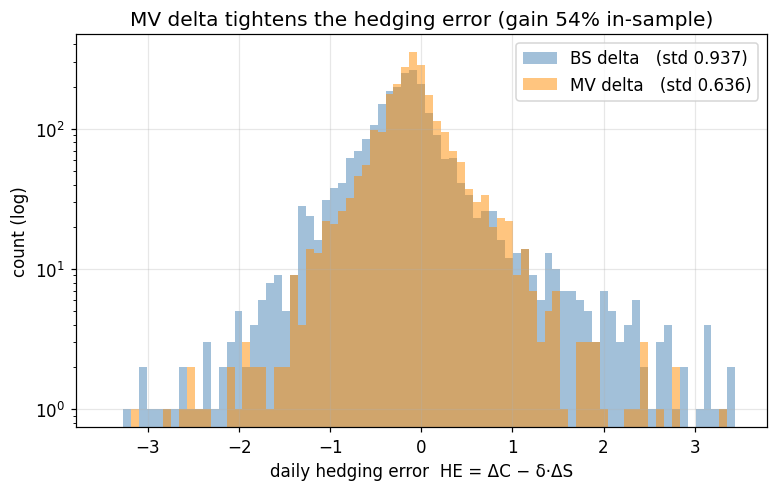

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
lim = np.percentile(np.abs(HE_bs), 99)
bins = np.linspace(-lim, lim, 80)
ax.hist(HE_bs, bins=bins, alpha=0.5, color=COLORS["bs"],
        label=f"BS delta   (std {HE_bs.std():.3f})")
ax.hist(HE_mv_full, bins=bins, alpha=0.5, color=COLORS["mv"],
        label=f"MV delta   (std {HE_mv_full.std():.3f})")
ax.set_yscale("log")
ax.set_xlabel("daily hedging error  HE = ΔC − δ·ΔS"); ax.set_ylabel("count (log)")
ax.set_title(f"MV delta tightens the hedging error (gain {g_is*100:.0f}% in-sample)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Verdict

In [6]:
print("V3 findings (real SPY + VIX,", len(df), "days):")
print("  leverage slope (dVIX vs return) :", round(slope, 2), "(strongly negative)")
print("  MV-delta gain, out-of-sample    :", round(g_oos * 100, 1), "%  (in-sample",
      round(g_is * 100, 1), "%)")
print("  benchmarks                      : GBM null 0%   |   Hull-White 2017 (real quotes) ~26%")
print()
print("Direction confirmed: the spot-vol leverage effect that the synthetic v0=theta world")
print("lacked makes a minimum-variance delta pay off out-of-sample -- versus a TRUE GBM null of")
print("0% (the synthetic -4% was a pinned-vol straw man). But the MAGNITUDE is inflated: with")
print("IV set literally = VIX, most of the hedging error is the vol move, so the MV correction")
print("is largely regressing dVIX on dS. The honest result is the positive SIGN vs a 0% null,")
print("benchmarked by Hull-White's ~26% on real option quotes -- not the headline percentage.")

V3 findings (real SPY + VIX, 2513 days):
  leverage slope (dVIX vs return) : -137.88 (strongly negative)
  MV-delta gain, out-of-sample    : 49.4 %  (in-sample 53.9 %)
  benchmarks                      : GBM null 0%   |   Hull-White 2017 (real quotes) ~26%

Direction confirmed: the spot-vol leverage effect that the synthetic v0=theta world
lacked makes a minimum-variance delta pay off out-of-sample -- versus a TRUE GBM null of
0% (the synthetic -4% was a pinned-vol straw man). But the MAGNITUDE is inflated: with
IV set literally = VIX, most of the hedging error is the vol move, so the MV correction
is largely regressing dVIX on dS. The honest result is the positive SIGN vs a 0% null,
benchmarked by Hull-White's ~26% on real option quotes -- not the headline percentage.


## Caveats (academic honesty)

- **Magnitude is construction-dependent and likely overstated.** We set the option's IV
  *equal* to VIX and reprice with next day's VIX, so the full daily VIX move flows into the
  option P&L and the MV correction (which predicts ΔVIX from ΔS) removes a large share,
  hence a gain well above the ~26% Hull–White (2017) report on **actual** option quotes,
  whose IVs are less volatile than VIX and do not track it one-for-one.  The robust,
  direction-of-effect result is **positive vs a 0% GBM null** (the synthetic −4% was a
  pinned-vol straw man), benchmarked by Hull–White's ~26% on real quotes, not the exact percentage.
- **In-sample (a,b,c).** Three coefficients fit to the data; the out-of-sample split guards
  against overfitting and the gain survives it.
- **One-day horizon, constant τ, no transaction costs.** A clean rolling ATM 1-month option;
  costs and discrete rebalancing would shrink the realised benefit.
- **VIX ≠ our option's IV.** VIX is a 30-day constant-maturity index vol, a proxy for a
  freshly-struck ATM 1-month SPY option's IV, not its exact quote.